In [4]:
# %matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix
# import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

11938
/media/work/docs/codes/QuCF/scripts-py


In [1]:
import numpy as np
np.__version__

import sys
print(sys.executable)

import os
workspace_folder = os.getcwd()  # Gets the current working directory
print("Workspace Folder:", workspace_folder)

/media/work/docs/codes/QuCF/scripts-py/env/bin/python
Workspace Folder: /media/work/docs/codes/QuCF/scripts-py/jupyter-notebooks/Stepanoff


In [2]:
path_save_ = "./jupyter-notebooks/Stepanoff/results/"
for i in range(100):
    plt.close()

In [3]:
# ---------------------------------------------------------------------------------------
def plot_matrix(
        A, Nx, 
        name_A = "", label_A = "", 
        step_tick = 10,
        fontsize = 30, marker_size = 80,
        text_coord_label = [1, 14],
        text_coord_name_A = [12, 1],
):
    def find_rows_columns(A):
        N = A.shape[0]
        rows_plot_1 = np.zeros(N*N)
        cols_plot_1 = np.zeros(N*N)
        N_nz_1 = 0
        for ir in range(N):
            for ic in range(N):
                if np.abs(A[ir, ic]) > 0:
                    N_nz_1 += 1
                    rows_plot_1[N_nz_1-1] = ir
                    cols_plot_1[N_nz_1-1] = ic
        rows_plot_1 = rows_plot_1[0:N_nz_1]
        cols_plot_1 = cols_plot_1[0:N_nz_1]
        return rows_plot_1, cols_plot_1
    # -----------------------------------------------
    marker_size = int(marker_size / (Nx/4.)**2)

    N = A.shape[0]
    rows_A, cols_A = find_rows_columns(A)

    fig1 = plt.figure(figsize=(11,10))
    ax = fig1.add_subplot(111)
    ax.scatter(cols_A, rows_A, color="red", s = marker_size) 
    plt.xlim(0, N - 1)
    plt.ylim(0, N - 1)
    plt.gca().invert_yaxis()
    plt.xlabel(r'$\textbf{columns}$', fontsize = fontsize)
    plt.ylabel(r"$\textbf{rows}$", fontsize = fontsize)
    plt.grid()

    plt.yticks(np.arange(0, N, step_tick))
    plt.xticks(np.arange(0, N, step_tick))

    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    if Nx > 4:
        # ax.set_xticks([])
        ax.tick_params(axis='both', which='major', labelbottom=False, labelleft=False)


    # ax.text(
    #     int(text_coord_label[0]), int(text_coord_label[1]), 
    #     r'$\textbf{' + label_A + '}$', fontsize=fontsize
    # )
    
    # ax.text(
    #     int(text_coord_name_A[0]), int(text_coord_name_A[1]), 
    #     r'$' + name_A + '$', fontsize=fontsize
    # )

    # --- Indicate blocks ---
    for ii in range(Nx):
        ax.hlines(y=ii * Nx - 0.5, xmin=0, xmax=N, linewidth=2, color='black')
        ax.vlines(x=ii * Nx - 0.5, ymin=0, ymax=N, linewidth=2, color='black')

    # --- plot diagonal ---
    for ii in range(0, Nx):
        ax.plot([ii*Nx,N], [0, N-ii*Nx], "--b")
    for ii in range(1, Nx):
        ax.plot([0,N-ii*Nx], [ii*Nx, N], "--b")

    plt.show()
    return
# ---------------------------------------------------------------------------------------
def plot_2D_from_1D(
        psi_1d, N, theta_grid, phi_grid, 
        fontsize = 30, linewidth = 4,
        str_title = ""
):
    # --- reshape 1D grids ---
    XX, YY = np.meshgrid(theta_grid, phi_grid)
    psi_2D = psi_1d.reshape((N, N))

    # --- parameters for the plot ---
    cmap = plt.get_cmap("coolwarm")
    psi_max = np.max(np.real(psi_1d))
    levels = np.linspace(-psi_max, psi_max, 101) 
    divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    # --- plot ---
    fig_2d = plt.figure(figsize=(14, 10))
    ax = fig_2d.add_subplot(111)

    # cs = ax.pcolormesh(XX, YY, psi_2D.real, cmap=cmap, norm=divnorm)
    # cb = fig_2d.colorbar(cs, ax = ax)
    # cb.ax.ticklabel_format(style="scientific")
    # cb.ax.tick_params(labelsize=fontsize) 

    cs = ax.contourf(XX, YY, psi_2D.real, cmap=cmap, levels = 100, norm=divnorm)
    cb = fig_2d.colorbar(cs, ax = ax)
    cb.ax.ticklabel_format(style="scientific")
    cb.ax.tick_params(labelsize=fontsize) 


    ax.set_xlabel('$\\theta/\\pi$', fontsize = fontsize)
    ax.set_ylabel('$\\phi/\\pi$', fontsize = fontsize)
    ax.set_title(str_title, fontsize = fontsize)
    ax.set_xlim(np.min(theta_grid), np.max(theta_grid))
    ax.set_ylim(np.min(phi_grid), np.max(phi_grid))
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    return
# ---------------------------------------------------------------------------------------

In [3]:
# ---------------------------------------------------------------------
# --- Classical simulations in real space ---
# ---------------------------------------------------------------------
import scipy.special
from matplotlib import colors
from scipy.sparse import csr_matrix
def create_matrix(n, alpha, sigma, mu):
    N = 1 << n
    N2 = N*N

    # --- assume that the angle grids are the same ---
    # angle_grid = np.linspace(0., 2.*np.pi, N)
    angle_grid = np.linspace(-np.pi, np.pi, N)
    d_angle = np.diff(angle_grid)[0] 
    h = 1./(2.*d_angle)

    # --- Stepanoff flow ---
    fV2 = lambda theta, phi: alpha_ * (1. - np.cos(theta - phi))
    fV1 = lambda theta, phi: fV2(theta, phi) + (1. - alpha_) * (1. - np.cos(phi))

    # --- coordinate convention ---
    fcoord = lambda coord1, coord2: coord2 * N + coord1

    # --- matrix ---
    M = np.zeros((N2, N2), dtype=complex)
    for ir1 in range(N):
        theta_curr = angle_grid[ir1]
        for ir2 in range(N):
            ir = fcoord(ir1, ir2)
            phi_curr = angle_grid[ir2]

            # --- right block sideband ---
            ic2 = ir2 + 1 if ir2 < (N-1) else 0

            ic1 = ir1 + 1 if ir1 < (N-1) else 0
            M[ir, fcoord(ic1, ic2)] = fV1(theta_curr, phi_curr) + fV2(theta_curr, phi_curr)

            ic1 = ir1 - 1 if ir1 > 0 else (N-1)
            M[ir, fcoord(ic1, ic2)] = - fV1(theta_curr, phi_curr) + fV2(theta_curr, phi_curr)

            # --- left block sideband ---
            ic2 = ir2 - 1 if ir2 > 0 else (N-1)

            ic1 = ir1 + 1 if ir1 < (N-1) else 0
            M[ir, fcoord(ic1, ic2)] = fV1(theta_curr, phi_curr) - fV2(theta_curr, phi_curr)

            ic1 = ir1 - 1 if ir1 > 0 else (N-1)
            M[ir, fcoord(ic1, ic2)] = - fV1(theta_curr, phi_curr) - fV2(theta_curr, phi_curr)
    M *= 1j * h
    M_sparse = csr_matrix(M)

    # --- Initial conditions ---
    # assuming the same initial distribution in both directions
    finit = lambda aa, mu1, sigma1: np.exp(sigma1 * np.cos(aa-mu1))
    psi_init = np.zeros(N2, dtype=complex)
    for ir1 in range(N):
        exp_theta = finit(angle_grid[ir1], mu, sigma)
        for ir2 in range(N):
            ir = fcoord(ir1, ir2)
            psi_init[ir] = exp_theta * finit(angle_grid[ir2], mu, sigma)

    Iv = scipy.special.iv(0, sigma)
    psi_init = psi_init / (Iv * Iv)   

    return M, M_sparse, angle_grid, angle_grid, psi_init, 
# ------------------------------------------------------------------------------
alpha_ = np.sqrt(20)
sigma_ = 1.0
mu_ = 0.0

n_ = 6
N_ = 1 << n_
N2_ = N_*N_

M_, M_sparse_, theta_grid_, phi_grid_, psi_init_ = create_matrix(n_, alpha_, sigma_, mu_)

In [ ]:
# --- Plotting the matrix ---
mix.is_Hermitian(M_, "M")
# mix.print_matrix(M_, n_in_row=N2_)
plot_matrix(M_, N_, "M", "M", step_tick=1)

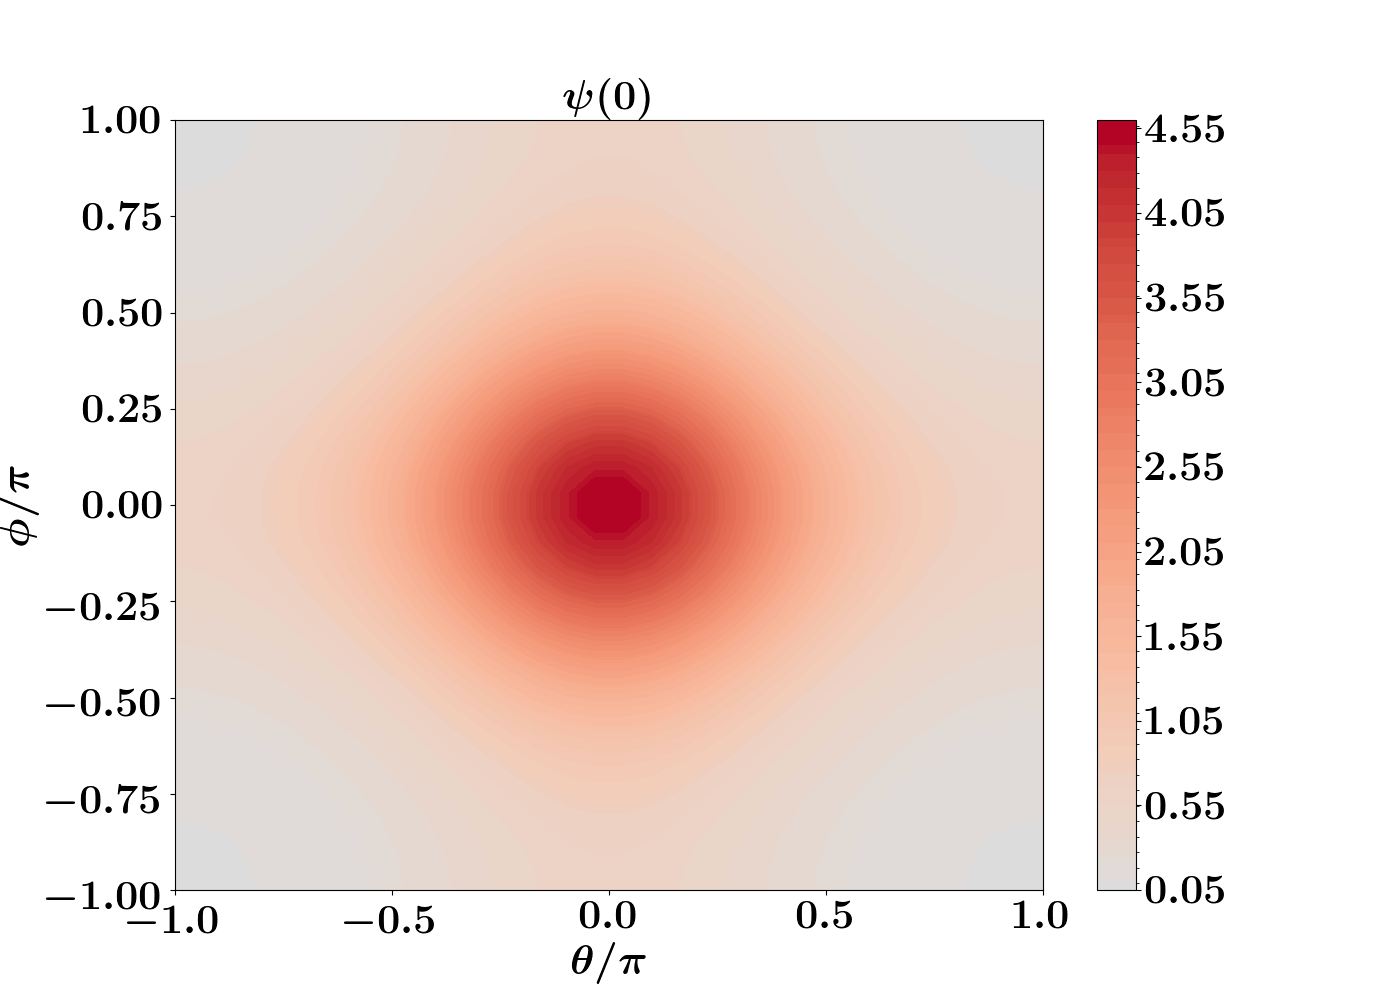

In [5]:
# --- Plotting initial conditions ---
plot_2D_from_1D(psi_init_, N_, theta_grid_/np.pi, phi_grid_/np.pi, str_title = '$\\psi(0)$')

In [12]:
# ------------------------------------------------------
# --- Solve the system ---
# ------------------------------------------------------
def solve_in_real_space(t, Nx, psi_init, M_sparse):
    Nt = len(t)
    dt = np.diff(t)[0]

    psi_tx      = np.zeros((Nt,Nx), dtype = complex)
    psi_tx[0,:] = np.array(psi_init)

    coef_dt = dt * (-1j)
    for it in range(Nt-1):
        Hpsi = M_sparse_.dot(psi_tx[it])

        for ix in range(1, Nx-1):
            psi_tx[it+1, ix] = psi_tx[it, ix] + coef_dt * Hpsi[ix]
    return psi_tx
# ----------------------------------------------------------------------
t_max = 1.
nt = 13
Nt = 1<<nt
t = np.linspace(0,t_max,Nt)

psi_tx_ = solve_in_real_space(t, N2_, psi_init_, M_sparse_)

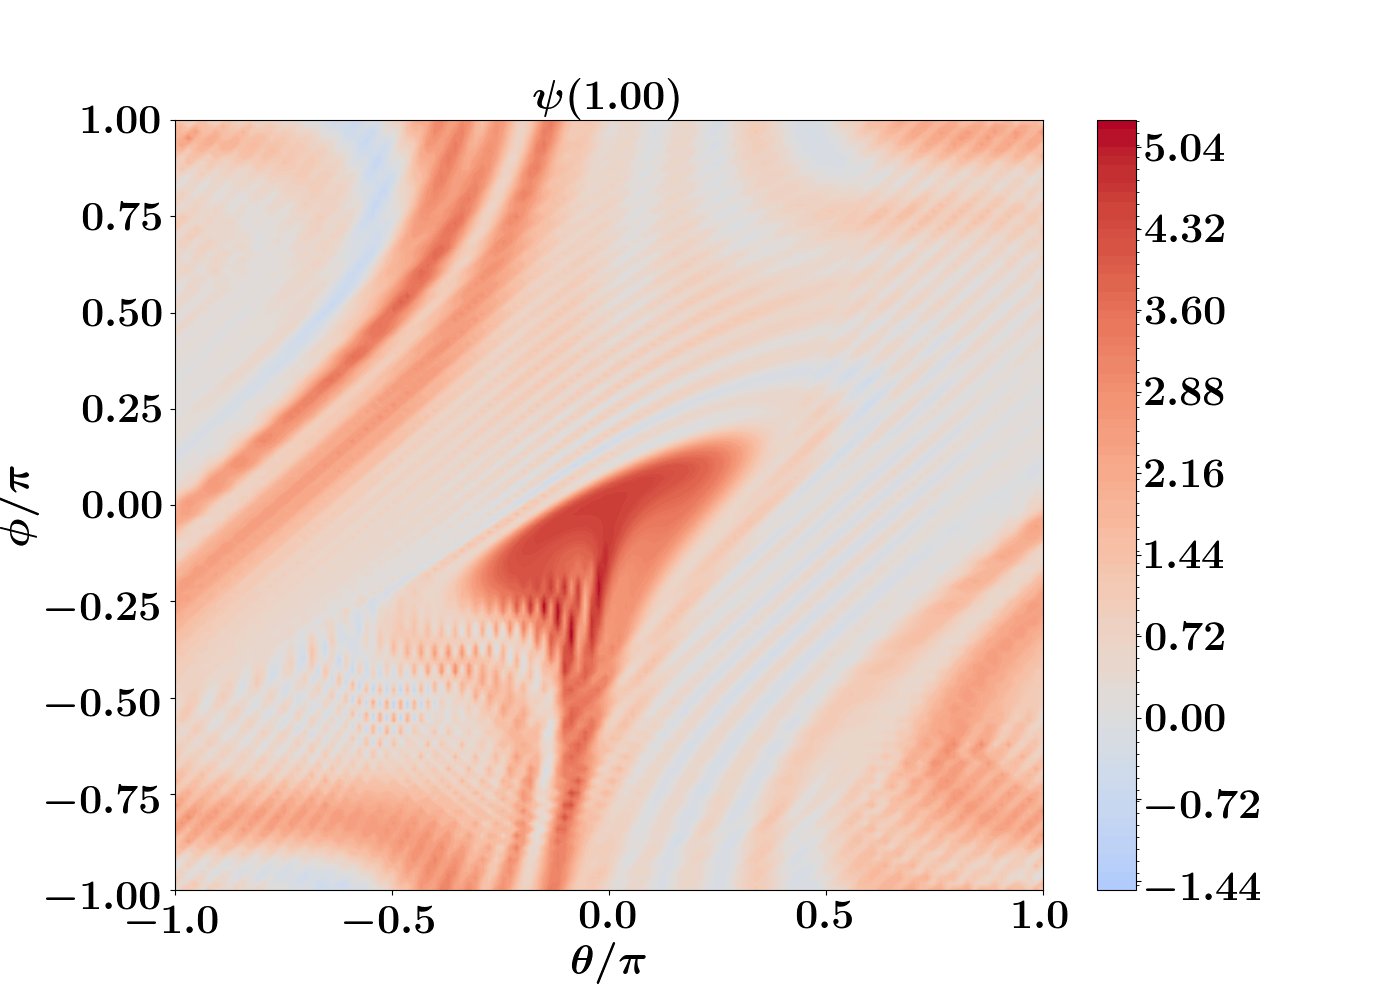

In [13]:
id_t = Nt//2
id_t = -1

plot_2D_from_1D(psi_tx_[id_t,:], N_, theta_grid_/np.pi, phi_grid_/np.pi, str_title = '$\\psi' + '({:0.2f})'.format(t[id_t]) + "$")

In [18]:
import numpy as np

# import jax.numpy as jnp
# from diffrax import Dopri5, ODETerm, PIDController, diffeqsolve
from scipy.stats import vonmises

from scipy.integrate import solve_ivp


def stepanoff_vec(alpha):
    """Vector field of the Stepanoff flow on the 2-torus"""
    def v(x):
        y = np.empty(2)
        y[1] = alpha * (1 - np.cos(x[0] - x[1]))
        y[0] = y[1] + (1 - alpha) * (1 - np.cos(x[1]))
        return y
    return v

def f_vm2pi(kappa, theta, phi):
    y = vonmises.pdf(theta, kappa[0], loc=np.pi) * vonmises.pdf(phi, kappa[1], loc=np.pi)
    return y


def f_RHS(t, y):
    # y = np.empty(2)
    y1, y2 = y
    dy2_dx = alpha * (1 - np.cos(y[0] - y[1]))
    dy1_dx = dy2_dx + (1 - alpha) * (1 - np.cos(y[1]))
    return [dy1_dx, dy2_dx]
# -------------------------------------------------
alpha = np.sqrt(20)

# n_plt_x = 4
# theta = np.linspace(0, 2 * np.pi, n_plt_x)
# x1, x2 = np.meshgrid(theta, theta)
# x = np.concatenate((x1[:-1, :-1, np.newaxis], x2[:-1, :-1, np.newaxis]), axis=2)
# x = np.reshape(x, ((n_plt_x - 1) ** 2, 2))
# x1 = x1 / np.pi
# x2 = x2 / np.pi

theta = theta_grid_ / np.pi
phi   = phi_grid_ / np.pi

# --- initial state ---
kappa = np.array([0.5,0.5])
y_init = f_vm2pi(kappa, theta, phi)



t = 4.
dt0 = 0.1

solution = solve_ivp(f_RHS, (0, 5), y_init, method='RK45', t_eval=np.linspace(0, 4, 6))

# # --- 
# RHS_term = ODETerm(f_RHS)
# solver = Dopri5()
# stepsize_controller = PIDController(rtol=1e-8, atol=1e-8)
# solution = diffeqsolve(
#     RHS_term,             # The ODE function
#     solver,               # The chosen solver (Dopri5)
#     t0=0,                 # Start time
#     t1=t,                 # End time
#     dt0=dt0,              # Initial step size
#     y0=y_init      # Initial condition
# )


ValueError: Terms are not compatible with solver!

In [ ]:
import jax.numpy as jnp
import diffrax

# Define the ODE: dy/dx = -y
def f(t, y, args):
    return -y

# Initial condition
y0 = jnp.array(1.0)  # y(0) = 1

# Define the solver
solver = diffrax.Dopri5()  # Dormand–Prince 5(4) method

# Define the time span
t0, t1 = 0, 5  # From x=0 to x=5
dt0 = 0.1  # Initial step size

# Solve the differential equation
solution = diffrax.diffeqsolve(
    diffrax.ODETerm(f),   # The ODE function
    solver,               # The chosen solver (Dopri5)
    t0=t0,                # Start time
    t1=t1,                # End time
    dt0=dt0,              # Initial step size
    y0=y0                 # Initial condition
)

# Print results
print("Times:", solution.ts)
print("Solutions:", solution.ys)

In [20]:
import numpy as np

import jax.numpy as jnp
from diffrax import Dopri5, ODETerm, PIDController, diffeqsolve
from scipy.stats import vonmises


def stepanoff_vec(alpha):
    """Vector field of the Stepanoff flow on the 2-torus"""
    def v(x):
        y = np.empty(2)
        y[1] = alpha * (1 - np.cos(x[0] - x[1]))
        y[0] = y[1] + (1 - alpha) * (1 - np.cos(x[1]))
        return y
    return v

def f_vm2pi(kappa):
    """Von Mises probability density on torus centered at (pi, pi)"""
    def f(x):
        y = vonmises.pdf(x[..., 0], kappa[0], loc=np.pi) \
            * vonmises.pdf(x[..., 1], kappa[1], loc=np.pi)
        return y
    return f

def f_RHS(t, x, args):
    y = stepanoff_vec(alpha)(x)
    return y
# -------------------------------------------------
alpha = np.sqrt(20)

n_plt_x = 4
theta = np.linspace(0, 2 * np.pi, n_plt_x)
x1, x2 = np.meshgrid(theta, theta)
x = np.concatenate((x1[:-1, :-1, np.newaxis], x2[:-1, :-1, np.newaxis]), axis=2)
x = np.reshape(x, ((n_plt_x - 1) ** 2, 2))
x1 = x1 / np.pi
x2 = x2 / np.pi

# --- initial state ---
kappa = np.array([0.5,0.5])
f_psi_init = f_vm2pi(kappa)

# --- 
RHS_term = ODETerm(f_RHS)
solver = Dopri5()
stepsize_controller = PIDController(rtol=1e-8, atol=1e-8)

t = 4.
dt0 = 0.1

# solution = diffeqsolve(
#     RHS_term,             # The ODE function
#     solver,               # The chosen solver (Dopri5)
#     t0=0,                 # Start time
#     t1=t,                 # End time
#     dt0=dt0,              # Initial step size
#     y0=f_psi_init(x)      # Initial condition
# )

In [21]:
f_psi_init(x)

array([0.008, 0.017, 0.017, 0.017, 0.037, 0.037, 0.017, 0.037, 0.037])

In [ ]:
# # ---------------------------------------------------------------------
# # --- Classical simulations in real space ---
# # ---------------------------------------------------------------------
# import scipy.special
# from matplotlib import colors

# def create_matrix(n, alpha, sigma, mu):
#     N = 1 << n
#     N2 = N*N

#     # --- assume that the angle grids are the same ---
#     # angle_grid = np.linspace(0., 2.*np.pi, N)
#     angle_grid = np.linspace(-np.pi, np.pi, N)
#     d_angle = np.diff(angle_grid)[0] 
#     h = 1./(2.*d_angle)

#     # --- Stepanoff flow ---
#     fV2 = lambda theta, phi: alpha_ * (1. - np.cos(theta - phi))
#     fV1 = lambda theta, phi: fV2(theta, phi) + (1. - alpha_) * (1. - np.cos(phi))

#     # --- coordinate convention ---
#     fcoord = lambda coord1, coord2: coord2 * N + coord1

#     # --- matrix ---
#     M = np.zeros((N2, N2), dtype=complex)
#     for ir1 in range(N):
#         theta_curr = angle_grid[ir1]
#         for ir2 in range(N):
#             ir = fcoord(ir1, ir2)
#             phi_curr = angle_grid[ir2]

#             # --- right block sideband ---
#             ic2 = ir2 + 1 if ir2 < (N-1) else 0

#             ic1 = ir1 + 1 if ir1 < (N-1) else 0
#             M[ir, fcoord(ic1, ic2)] = fV1(theta_curr, phi_curr) + fV2(theta_curr, phi_curr)

#             ic1 = ir1 - 1 if ir1 > 0 else (N-1)
#             M[ir, fcoord(ic1, ic2)] = - fV1(theta_curr, phi_curr) + fV2(theta_curr, phi_curr)

#             # --- left block sideband ---
#             ic2 = ir2 - 1 if ir2 > 0 else (N-1)

#             ic1 = ir1 + 1 if ir1 < (N-1) else 0
#             M[ir, fcoord(ic1, ic2)] = fV1(theta_curr, phi_curr) - fV2(theta_curr, phi_curr)

#             ic1 = ir1 - 1 if ir1 > 0 else (N-1)
#             M[ir, fcoord(ic1, ic2)] = - fV1(theta_curr, phi_curr) - fV2(theta_curr, phi_curr)
#     M *= 1j * h

#     # --- Initial conditions ---
#     # assuming the same initial distribution in both directions
#     finit = lambda aa: np.exp(sigma * np.cos(aa-mu))

#     psi_init = np.zeros(N2, dtype=complex)
#     for ir1 in range(N):
#         exp_theta = finit(angle_grid[ir1])
#         for ir2 in range(N):
#             ir = fcoord(ir1, ir2)
#             psi_init[ir] = exp_theta * finit(angle_grid[ir2])

#     Iv = scipy.special.iv(0, sigma)
#     psi_init = psi_init / (Iv * Iv)   

#     return M, angle_grid, angle_grid, psi_init
# # ------------------------------------------------------------------------------
# def plot_2D_from_1D(psi_1d, N, theta_grid, phi_grid, fontsize = 30, linewidth = 4):
#     # --- reshape 1D grids ---
#     XX, YY = np.meshgrid(theta_grid, phi_grid)
#     psi_2D = psi_1d.reshape((N, N))

#     # --- parameters for the plot ---
#     # cmap = 'coolwarm'
#     cmap = plt.get_cmap("coolwarm")


#     z_max = np.max(np.real(psi_1d))
#     # symmetric_vmin = -z_max  
#     # divnorm=colors.TwoSlopeNorm(vmin=symmetric_vmin, vcenter=0., vmax=z_max)

#     levels = np.linspace(-z_max, z_max, 101) 
#     divnorm = colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

#     # --- plot ---
#     fig_2d = plt.figure(figsize=(14, 10))
#     ax = fig_2d.add_subplot(111)

#     # cs = ax.contourf(
#     #     XX, YY, np.transpose(psi_2D.real), 
#     #     levels=100, 
#     #     cmap=cmap, 
#     #     # norm=divnorm
#     #     norm=colors.CenteredNorm()
#     # )


#     cs = ax.pcolormesh(
#         XX, YY, np.transpose(psi_2D.real), 
#         cmap=cmap, 
#         norm=divnorm
#         # norm=colors.CenteredNorm()
#     )



#     cb = fig_2d.colorbar(cs, ax = ax)
#     # cb.ax.ticklabel_format(style="scientific")
#     # cb.ax.tick_params(labelsize=fontsize) 

#     # cb.ax.set_yscale('linear')


#     # ax.set_xlabel('$\\theta$', fontsize = fontsize)
#     # ax.set_ylabel('$\\phi$', fontsize = fontsize)
#     # # ax.set_title(str_title + '$\psi(t,x)$' + str_Diff_title, fontsize = fontsize)
#     # # ax.set_xlim(0, t_max)
#     # # ax.set_ylim(-x_max, x_max)
#     # ax.tick_params(axis='both', which='major', labelsize=fontsize)
#     return
# # ------------------------------------------------------------------------------
# alpha_ = np.sqrt(20)
# sigma_ = 0.5
# mu_ = 0.0

# n_ = 5
# N_ = 1 << n_
# N2_ = N_*N_

# M, theta_grid_, phi_grid_, psi_init_ = create_matrix(n_, alpha_, sigma_, mu_)

# # --- Plotting initial conditions ---
# plot_2D_from_1D(psi_init_, N_, theta_grid_, phi_grid_)


# # # --- Plotting the matrix ---
# # mix.is_Hermitian(M, "M")
# # # mix.print_matrix(M, n_in_row=N2_)
# # plot_matrix(M, N_, "M", "M", step_tick=1)